In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import pandas as pd
import xarray as xr
import cf_xarray as cf
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

In [2]:
def windSpd(u,v):
   windSpd=np.sqrt(u**2 + v**2)
   return windSpd

In [33]:
### +++ DATA PATHS +++ ###
dpath0 = '/discover/nobackup/projects/giss/baldwin_nip/dmkumar'
opath  = '/home/dmkumar/JupyterLinks/notebooks/topo_nam/figs'

flor_pi_runs  = ['ctrl', 'hicam', 'hitopo']
flor_2x_runs  = ['ctrl', 'hitopo']
varns         = ['u700', 'v700', 'h700']

files = {
    'obs':   {'merra2': {}},
    'pi':    {'ctrl': {}, 'hicam':{}, 'hitopo': {}},
    '2xco2': {'ctrl': {}, 'hitopo': {}},
    'topo':  {}
}

# MERRA-2 Reanalysis
files['obs']['merra2']['u700'] = f'{dpath0}/obs_data/merra2/merra2.U.1980-2022.monthly.nc' 
files['obs']['merra2']['v700'] = f'{dpath0}/obs_data/merra2/merra2.V.1980-2022.monthly.nc' 
files['obs']['merra2']['h700'] = f'{dpath0}/obs_data/merra2/merra2.H.1980-2022.monthly.nc'

# CM2.5-FLOR Runs
for run in flor_pi_runs:
    for varn in varns:
        files['pi'][run][varn]    = f'{dpath0}/FLOR/{run}/pi/flor.{run}.{varn}.monthly.nc'
for run in flor_2x_runs:    
    files['2xco2'][run][varn] = f'{dpath0}/FLOR/{run}/2xco2/flor.{run}.2xco2.{varn}.monthly.nc'

# Obs & Model Topography
files['topo']['etopo']  = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
files['topo']['ctrl']   = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
files['topo']['hicam']  = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
files['topo']['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [35]:
### +++ LOAD DATA +++ ###

# lat lon bounds
latmin = 10
latmax = 70
lonmin = 200
lonmax = 300
# time bounds
n_keep_years = 100
n_keep_mons  = -1 * (n_keep_years * 12)

# initialize dictionaries
dat = {
    'obs': {'merra2': {}},
    'pi':  {'ctrl': {}, 'hicam':{}, 'hitopo': {}}
}
topo = {}

# --- Read in raw fields --- #
print('Loading data...')

# MERRA-2: select 700 hPa level
print('-> MERRA-2')
for varn, mvarn in zip(varns, ['U','V','H']):
    ds = xr.open_dataset(files['obs']['merra2'][varn])[mvarn].sel(lev=700).squeeze(drop=True)
    dat['obs']['merra2'][varn] = lonFlip(ds).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
    del ds

# CM2.5-FLOR PI: last 100 years
print('-> CM2.5-FLOR')
for run in flor_pi_runs:
    for varn in varns:
        dat['pi'][run][varn] = xr.open_dataset(files['pi'][run][varn])[varn][n_keep_mons:].rename({'grid_xt': 'lon', 'grid_yt': 'lat'}).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

# --- Calculate speed of 700 hPa winds --- #
print('\nCalculating wind speed...')
dat['obs']['merra2']['spd700'] = windSpd(dat['obs']['merra2']['u700'],dat['obs']['merra2']['v700'])
for run in flor_pi_runs:
    dat['pi'][run]['spd700'] = windSpd(dat['pi'][run]['u700'],dat['pi'][run]['v700'])
    
# --- Calculate stationary wave pattern in 700 hPa geopotential heights --- #
print('\nCalculating stationary wave patterns...')
dat['obs']['merra2']['swp700'] = dat['obs']['merra2']['h700'] - dat['obs']['merra2']['h700'].mean(dim='lon')
for run in flor_pi_runs:
    dat['pi'][run]['swp700'] = dat['pi'][run]['h700'] - dat['pi'][run]['h700'].mean(dim='lon')

# --- Read in surface topography fields --- #
print('\nLoading topography fields...')
ds = xr.open_dataset(files['topo']['etopo']).ROSE.rename({'ETOPO05_X': 'lon', 'ETOPO05_Y': 'lat'})
topo['etopo'] = ds.where(ds > 0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
del ds
for run in flor_pi_runs:
    topo[run] = xr.open_dataset(files['topo'][run]).ZSURF.rename({'GRID_XT': 'lon', 'GRID_YT': 'lat'}).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

print('\nDone.')

Loading data...
-> MERRA-2
-> CM2.5-FLOR

Calculating wind speed...

Calculating stationary wave patterns...

Loading topography fields...

Done.


In [36]:
### +++ JAS SEASONAL MEANS +++ ###
season = 'JAS'
mons   = [7, 8, 9]
varns  = ['u700', 'v700', 'h700', 'spd700', 'swp700']

jas_mean = {
    'obs': {'merra2': {}},
    'pi':  {'ctrl': {}, 'hicam':{}, 'hitopo': {}}
}
ann_jas_mean = {
    'obs': {'merra2': {}},
    'pi':  {'ctrl': {}, 'hicam':{}, 'hitopo': {}}
}

print('Calculating JAS means...')
for key, runs in [('obs', ['merra2']), ('pi', flor_pi_runs)]:
    for run in runs:
        for varn in varns:
            da = dat[key][run][varn]
            custom_seasons = xr.where(da['time'].dt.month.isin(mons), season, 'Other')
            jas_mean[key][run][varn]     = da.groupby(custom_seasons).mean('time').rename({'month': 'season'}).sel(season=season)
            ann_jas_mean[key][run][varn] = da.sel(time=da['time'].dt.month.isin(mons)).groupby('time.year').mean(dim='time')
print('Done.')

Calculating JAS means...
Done.


In [ ]:
### +++ MODEL BIAS (MODEL - OBS) +++ ###

jas_mean_regrid     = {'obs_flor': {}}
ann_jas_mean_regrid = {'obs_flor': {}}
obs_diff      = {'pi': {'ctrl': {}, 'hicam':{}, 'hitopo': {}}}
obs_diff_mask = {'pi': {'ctrl': {}, 'hicam':{}, 'hitopo': {}}}
obs_ptvals    = {'pi': {'ctrl': {}, 'hicam':{}, 'hitopo': {}}}

# Regrid obs to model grid
print('Re-gridding obs to model grid...\n')
lats = dat['pi']['ctrl']['h700'].lat
lons = dat['pi']['ctrl']['h700'].lon
for varn in varns:
    jas_mean_regrid['obs_flor'][varn]     = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
    ann_jas_mean_regrid['obs_flor'][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')

# Significance testing of fields
print('Significance testing (model - obs)...\n')
for run in flor_pi_runs:
    print(f'\n-> {run}')
    for varn in varns:
        print(f'---> {varn}')
        diff_, mask_, pvals_ = sigtest2n(ann_jas_mean['pi'][run][varn], ann_jas_mean_regrid['obs_flor'][varn],
                                         jas_mean['pi'][run][varn],  jas_mean_regrid['obs_flor'][varn])
        obs_diff['pi'][run][varn]      = diff_
        obs_diff_mask['pi'][run][varn] = mask_
        obs_ptvals['pi'][run][varn]    = pvals_


# Mask vectors where both are significant
obs_usig = {'pi': {'ctrl': {}, 'hicam':{}, 'hitopo': {}}}
obs_vsig = {'pi': {'ctrl': {}, 'hicam':{}, 'hitopo': {}}}

key='pi'
for run in flor_pi_runs:
    obs_usig[key][run] = np.where((obs_diff_mask[key][run]['u700'].mask==False) &
                                  (obs_diff_mask[key][run]['v700'].mask==False),
                                  obs_diff_mask[key][run]['u700'].data, np.nan)
    obs_vsig[key][run] = np.where((obs_diff_mask[key][run]['u700'].mask==False) &
                                  (obs_diff_mask[key][run]['v700'].mask==False),
                                  obs_diff_mask[key][run]['v700'].data, np.nan)

print('\nDone.')

In [20]:
### +++ TOPO SENSITIVITY (Modified_Topo - CTRL) +++ ###

model_diff      = {'pi': {'hicam':{}, 'hitopo': {}}}
model_diff_mask = {'pi': {'hicam':{}, 'hitopo': {}}}
model_ptvals    = {'pi': {'hicam':{}, 'hitopo': {}}}

print('Significance testing (modified - ctrl)...')

for run in model_diff['pi'].keys():
    print(f'\n-> {run}')
    for varn in varns:
        print(f'---> {varn}')
        diff_, mask_, pvals_ = sigtest2n(ann_jas_mean['pi'][run][varn], ann_jas_mean['pi']['ctrl'][varn],
                                          jas_mean['pi'][run][varn], jas_mean['pi']['ctrl'][varn])
        model_diff['pi'][run][varn]      = diff_
        model_diff_mask['pi'][run][varn] = mask_
        model_ptvals['pi'][run][varn]    = pvals_

# Mask vectors where both are significant
model_usig = {'pi': {'hicam':{}, 'hitopo': {}}}
model_vsig = {'pi': {'hicam':{}, 'hitopo': {}}}

key='pi'
for run in flor_pi_runs:
    model_usig[key][run] = np.where((model_diff_mask[key][run]['u700'].mask==False) &
                                    (model_diff_mask[key][run]['v700'].mask==False),
                                    model_diff_mask[key][run]['u700'].data, np.nan)
    model_vsig[key][run] = np.where((model_diff_mask[key][run]['u700'].mask==False) &
                                    (model_diff_mask[key][run]['v700'].mask==False),
                                    model_diff_mask[key][run]['v700'].data, np.nan)

print('\nDone.')

Significance testing (modified - ctrl)...

-> hicam
---> u700
---> v700
---> h700
---> swp700

-> hitopo
---> u700
---> v700
---> h700
---> swp700

Done.


## FIGURES

### h700 climatology and stationary wave pattern

KeyError: 'etopo'

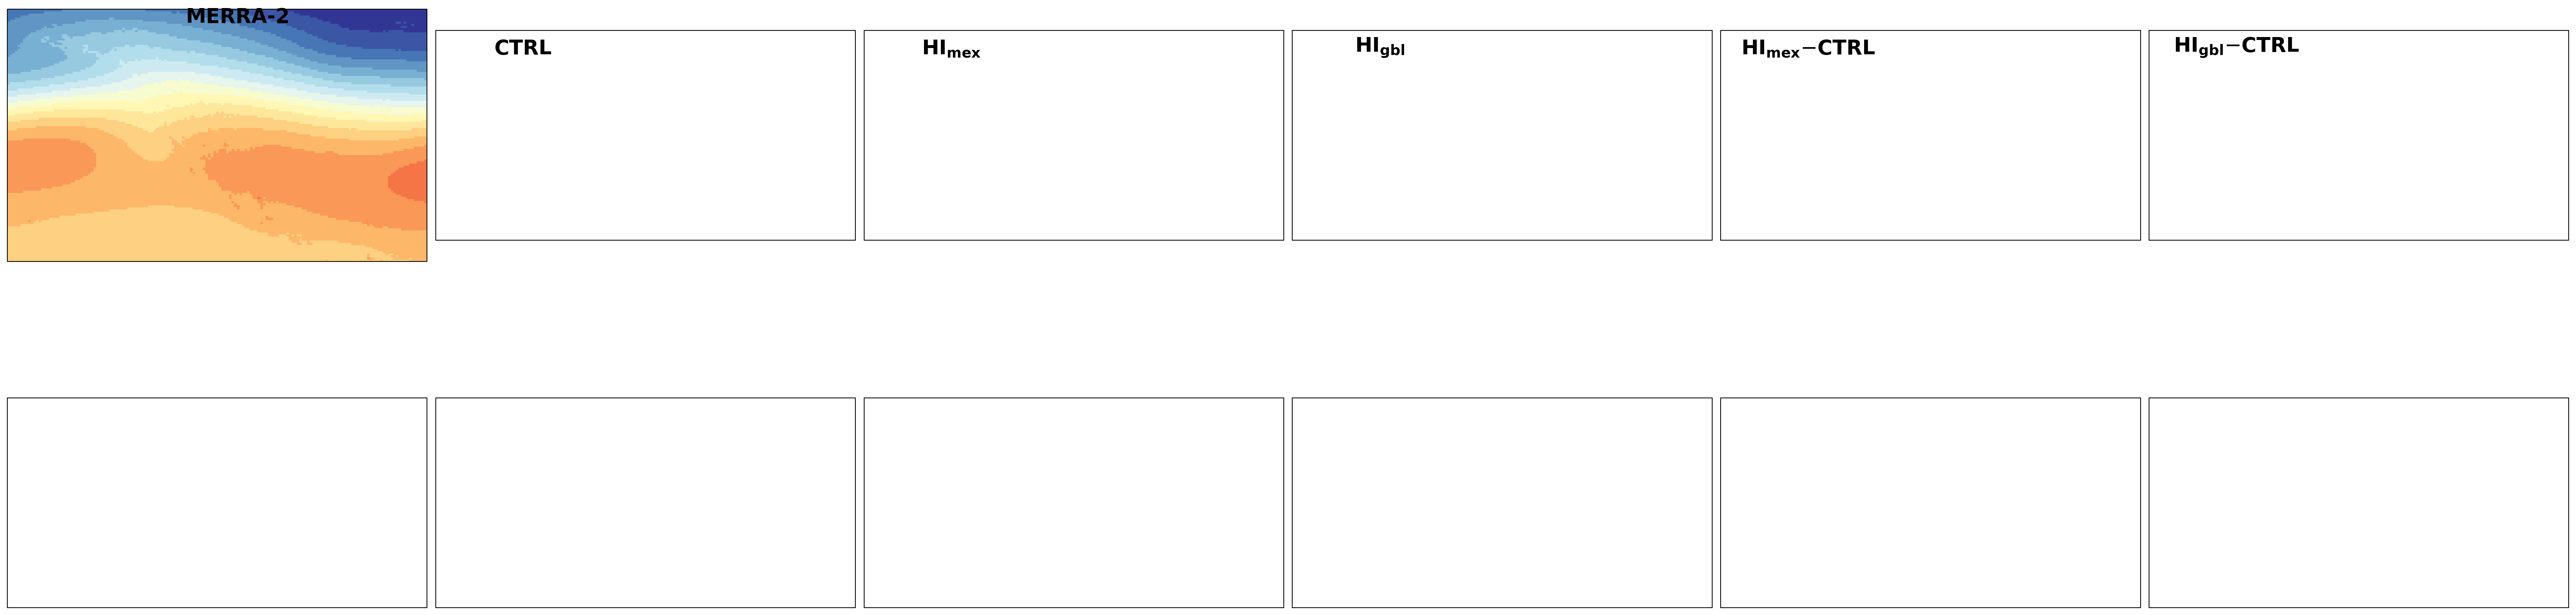

In [32]:
# -------------------- #
#       Settings       #
# -------------------- #
# plot specs
lw=1
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
letters=['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
tx=-105
ty=66
# var specs
lon = jas_mean['pi']['ctrl']['h700'].lon
lat = jas_mean['pi']['ctrl']['h700'].lat
# topography contours
zlevels=np.linspace(1000,4000,8)
# h500 colormap
cmap=cm.RdYlBu_r
vmin=2900
vmax=3300
levels=np.linspace(vmin, vmax, 21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
hlevels=np.arange(vmin-50, vmax+50, 25)
# swp500 colormap
dcmap=cm.RdBu_r
dvmin=-50
dvmax=50
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# diff colormap
dcmap2=cmo.balance
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,290,10,65]
cols=[0,2]

fig, ax = plt.subplots(nrows=2, ncols=6, figsize=(35,10), layout='constrained', subplot_kw={'projection':proj})

for i,title in enumerate(['MERRA-2', 'CTRL', r'HI$\mathbf{_{mex}}$', r'HI$\mathbf{_{gbl}}$', r'HI$\mathbf{_{mex}}$$-$CTRL', r'HI$\mathbf{_{gbl}}$$-$CTRL']):
    ax[0,i].text(tx, ty, title, **text_kw)
    
#=== OBS ===
mlon = jas_mean['obs']['merra2']['h700'].lon
mlat = jas_mean['obs']['merra2']['h700'].lat
ax[0,0].pcolormesh(mlon, mlat, jas_mean['obs']['merra2']['h700'].squeeze(), cmap=cmap, norm=norm, transform=trans)
ax[0,0].contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=np.linspace(1000,4000,4), linewidths=1, colors='black', transform=trans)

ax[1,0].pcolormesh(mlon, mlat, jas_mean['obs']['merra2']['swp700'].squeeze(), cmap=dcmap, norm=dnorm, transform=trans)
ax[1,0].contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=np.linspace(1000,4000,4), linewidths=1, colors='black', transform=trans)

#=== FLOR ===
ax[0,1].pcolormesh(lon, lat, jas_mean['pi']['ctrl']['h700'], cmap=cmap, norm=norm, transform=trans)
ax[0,2].pcolormesh(lon, lat, jas_mean['pi']['hicam']['h700'], cmap=cmap, norm=norm, transform=trans)
cf=ax[0,3].pcolormesh(lon, lat, jas_mean['pi']['hitopo']['h700'], cmap=cmap, norm=norm, transform=trans)

ax[1,1].pcolormesh(lon, lat, jas_mean['pi']['ctrl']['swp700'], cmap=dcmap, norm=dnorm, transform=trans)
ax[1,2].pcolormesh(lon, lat, jas_mean['pi']['hicam']['swp700'], cmap=dcmap, norm=dnorm, transform=trans)
cf2=ax[1,3].pcolormesh(lon, lat, jas_mean['pi']['hitopo']['swp700'], cmap=dcmap, norm=dnorm, transform=trans)

for i,run in enumerate(['ctrl','hicam','hitopo']):
    ax[0,i+1].contour(lon, lat, topo[run], levels=zlevels, linewidths=1, colors='black', transform=trans)
    ax[1,i+1].contour(lon, lat, topo[run], levels=zlevels, linewidths=1, colors='black', transform=trans)

#=== FLOR CHANGE ===
ax[0,4].text(-165,40,' ')
ax[0,4].pcolormesh(lon, lat, model_diff['pi']['hicam']['h700'], cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-100, 100, 21), dcmap2.N), transform=trans)
cf3=ax[0,5].pcolormesh(lon, lat, model_diff['pi']['hitopo']['h700'], cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-100, 100, 21), dcmap2.N), transform=trans)

ax[1,4].pcolormesh(lon, lat, model_diff['pi']['hicam']['swp700'], cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-16, 16, 17), dcmap2.N), transform=trans)
cf4=ax[1,5].pcolormesh(lon, lat, model_diff['pi']['hitopo']['swp700'], cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-16, 16, 17), dcmap2.N), transform=trans)

ax[0,4].contour(lon, lat, topo['hicam']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)
ax[1,4].contour(lon, lat, topo['hicam']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)
ax[0,5].contour(lon, lat, topo['hitopo']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)
ax[1,5].contour(lon, lat, topo['hitopo']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-136, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1.5)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# h500
cax=fig.add_axes([.64, .55, 0.0125, 0.4])
cbar=fig.colorbar(cf, ticks=np.linspace(2900,3300,9), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('700 hPa Geopotential Height [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# swp500
cax=fig.add_axes([.64, .05, 0.0125, 0.4])
cbar=fig.colorbar(cf2, ticks=np.linspace(-50,50,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('700 hPa Stationary Wave Pattern [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# h500 change
cax=fig.add_axes([1.005, .55, 0.0125, 0.4])
cbar=fig.colorbar(cf3, ticks=np.linspace(-100,100,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('$\Delta$ 700 hPa Geopotential Height [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# swp500 change
cax=fig.add_axes([1.005, .05, 0.0125, 0.4])                                 
cbar=fig.colorbar(cf4, ticks=np.linspace(-16,16,9), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('$\Delta$ 700 hPa Stationary Wave Pattern [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)

#plt.savefig(f'figs/h700.swp.flor.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(f'figs/h700.swp.flor.png', transparent=False, bbox_inches='tight')